# Temporal Modelling of Syscall Behaviour with Bidirectional LSTM

This stage evaluates whether modelling execution order improves intrusion detection beyond frequency-based representations. The model family is designed to capture dependencies across time, allowing the classifier to exploit behavioural motifs that are invisible in order-agnostic vectors.

The key scientific issue is whether this temporal capacity translates into robust gains under scenario-based evaluation, rather than isolated improvements driven by threshold effects.

## Architectural Rationale and Training Discipline

Bidirectional recurrence is used to encode each timestep with both preceding and following context, while attention pooling concentrates the decision on informative regions of the sequence. Packed sequence handling prevents padding from contaminating recurrent dynamics, which is essential given the broad length variability in ADFA-LD.

The optimisation protocol combines imbalance-aware loss scaling, weighted sampling, gradient clipping, and early stopping. This combination is intended to stabilise training on limited data while preserving attack sensitivity.

In [2]:
from itertools import product
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import WeightedRandomSampler
import yaml

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.datasets as datasets_module
import src.evaluate as evaluate_module
import src.lstm_model as lstm_model_module
import src.train as train_module
importlib.reload(datasets_module)
importlib.reload(evaluate_module)
importlib.reload(lstm_model_module)
importlib.reload(train_module)

SyscallSequenceDataset = datasets_module.SyscallSequenceDataset
make_dataloader = datasets_module.make_dataloader
build_prediction_frame = evaluate_module.build_prediction_frame
evaluate_lstm_classifier = evaluate_module.evaluate_lstm_classifier
find_best_threshold = evaluate_module.find_best_threshold
LSTMClassifier = lstm_model_module.LSTMClassifier
fit_lstm = train_module.fit_lstm

from src.metrics import save_confusion_matrix_plot
from src.utils import RESULTS_ROOT, PROCESSED_ROOT, ensure_dir, set_seed

sns.set_theme(style='whitegrid', context='talk')

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'default.yaml'
with CONFIG_PATH.open('r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

seed = int(cfg.get('project', {}).get('seed', 42))
set_seed(seed)
torch.manual_seed(seed)

lstm_cfg = cfg.get('lstm', {})
version_tag = str(lstm_cfg.get('processed_version', 'protocol_a_main_ml1231_dualview_v1'))
version_dir = PROCESSED_ROOT / version_tag
index_path = version_dir / 'adfa_processed_index.parquet'
seq_post_path = version_dir / 'adfa_sequences_post.npy'
seq_pre_path = version_dir / 'adfa_sequences_pre.npy'

if not index_path.exists():
    raise FileNotFoundError(index_path)
if not seq_post_path.exists() or not seq_pre_path.exists():
    raise FileNotFoundError('Missing encoded sequence arrays for pre/post views')

index_df = pd.read_parquet(index_path)
seq_post = np.load(seq_post_path)
seq_pre = np.load(seq_pre_path)

vocab_size = int(max(int(seq_post.max()), int(seq_pre.max())) + 1)
pad_value = 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Rows:', len(index_df), '| Vocab size:', vocab_size)

Device: cpu
Rows: 5951 | Vocab size: 152


In [3]:
def build_split_pack(view_name):
    if view_name == 'post':
        seq_array = seq_post
        effective_len_col = 'len_after_post'
    elif view_name == 'pre':
        seq_array = seq_pre
        effective_len_col = 'len_after_pre'
    else:
        raise ValueError(view_name)

    if effective_len_col not in index_df.columns:
        raise ValueError(f'Missing required column: {effective_len_col}')

    df = index_df.reset_index(drop=True).copy()
    lengths = df[effective_len_col].fillna(0).astype(int).tolist()
    seq_list = []
    for arr, eff_len in zip(seq_array, lengths):
        k = max(1, int(eff_len))
        seq_list.append(arr[:k].tolist())
    df['encoded_view'] = seq_list

    split_pack = {}
    for split in ['train', 'val', 'test']:
        sdf = df[df['split'] == split].reset_index(drop=True)
        split_pack[split] = {
            'df': sdf,
            'x': sdf['encoded_view'].tolist(),
            'y': sdf['label_binary'].astype(int).tolist(),
            'trace_ids': sdf['trace_id'].astype(str).tolist(),
        }
    return split_pack


def make_loaders(split_pack, batch_size=64, use_weighted_sampler=False):
    loaders = {}
    for split in ['train', 'val', 'test']:
        ds = SyscallSequenceDataset(
            encoded_sequences=split_pack[split]['x'],
            labels=split_pack[split]['y'],
            sample_ids=split_pack[split]['trace_ids'],
            return_metadata=False,
        )

        sampler = None
        shuffle = split == 'train'
        if split == 'train' and use_weighted_sampler:
            y = np.asarray(split_pack['train']['y'], dtype=np.int64)
            class_counts = np.bincount(y, minlength=2)
            class_weights = np.array([
                1.0 / max(1, class_counts[0]),
                1.0 / max(1, class_counts[1]),
            ])
            sample_weights = class_weights[y]
            sampler = WeightedRandomSampler(
                weights=torch.as_tensor(sample_weights, dtype=torch.double),
                num_samples=len(sample_weights),
                replacement=True,
            )
            shuffle = False

        loaders[split] = make_dataloader(
            dataset=ds,
            batch_size=batch_size,
            shuffle=shuffle,
            pad_value=pad_value,
            sort_by_length=False,
            num_workers=int(cfg.get('training', {}).get('num_workers', 0)),
            sampler=sampler,
        )
    return loaders

In [ ]:
ablation_cfg = lstm_cfg.get('ablation', {})
model_cfg = lstm_cfg.get('model', {})
training_cfg = cfg.get('training', {})
imbalance_cfg = cfg.get('imbalance', {})
thr_cfg = cfg.get('threshold_optimization', {})

embedding_dims = [int(x) for x in ablation_cfg.get('embedding_dims', [64, 128])]
hidden_sizes = [int(x) for x in ablation_cfg.get('hidden_sizes', [128, 256])]
dropouts = [float(x) for x in ablation_cfg.get('dropouts', [0.1, 0.3, 0.5])]
views = [str(v) for v in lstm_cfg.get('views', ['post', 'pre'])]

num_epochs = int(lstm_cfg.get('num_epochs', 20))
lr = float(training_cfg.get('lr', 1e-3))
weight_decay = float(training_cfg.get('weight_decay', 1e-4))
batch_size = int(training_cfg.get('batch_size', 64))
grad_clip = float(training_cfg.get('grad_clip', 1.0))
early_stopping_patience = int(training_cfg.get('early_stopping_patience', 5))

bidirectional = bool(model_cfg.get('bidirectional', True))
use_attention = bool(model_cfg.get('use_attention', True))
num_layers = int(model_cfg.get('num_layers', 2))

use_pos_weight = bool(imbalance_cfg.get('use_pos_weight', True))
use_weighted_sampler = bool(imbalance_cfg.get('use_weighted_sampler', True))

use_threshold_optimization = bool(thr_cfg.get('enabled', True))
threshold_metric = str(thr_cfg.get('metric', 'f1'))
max_fpr = thr_cfg.get('max_fpr', None)

ckpt_dir = ensure_dir(RESULTS_ROOT / 'logs' / 'checkpoints')
tables_dir = ensure_dir(RESULTS_ROOT / 'tables')
cm_dir = ensure_dir(RESULTS_ROOT / 'confusion_matrices')
fig_dir = ensure_dir(PROJECT_ROOT / 'reports' / 'figures')

rows = []
all_histories = []
best_run = None
best_val_f1 = -1.0

for view_name, emb_dim, hid_size, dropout in product(views, embedding_dims, hidden_sizes, dropouts):
    split_pack = build_split_pack(view_name)
    loaders = make_loaders(split_pack, batch_size=batch_size, use_weighted_sampler=use_weighted_sampler)

    y_train_arr = np.asarray(split_pack['train']['y'], dtype=np.int64)
    n_pos = int((y_train_arr == 1).sum())
    n_neg = int((y_train_arr == 0).sum())
    pos_weight = (n_neg / max(1, n_pos)) if use_pos_weight else None

    run_name = f'lstm_{view_name}_e{emb_dim}_h{hid_size}_d{dropout}'
    ckpt_path = ckpt_dir / f'{run_name}.pt'

    model = LSTMClassifier(
        vocab_size=vocab_size,
        embedding_dim=emb_dim,
        hidden_size=hid_size,
        num_layers=num_layers,
        dropout=dropout,
        padding_idx=pad_value,
        bidirectional=bidirectional,
        use_attention=use_attention,
    )

    history, best_summary = fit_lstm(
        model=model,
        train_loader=loaders['train'],
        val_loader=loaders['val'],
        num_epochs=num_epochs,
        lr=lr,
        weight_decay=weight_decay,
        device=device,
        checkpoint_path=ckpt_path,
        grad_clip=grad_clip,
        early_stopping_patience=early_stopping_patience,
        pos_weight=pos_weight,
        decision_threshold=0.5,
    )

    all_histories.append(pd.DataFrame(history).assign(run_name=run_name))

    val_eval_base = evaluate_lstm_classifier(model, loaders['val'], device=device, threshold=0.5)
    chosen_threshold = 0.5
    val_eval = val_eval_base

    if use_threshold_optimization:
        thr_pack = find_best_threshold(
            y_true=val_eval_base['y_true'],
            y_score=val_eval_base['y_score'],
            metric=threshold_metric,
            max_fpr=max_fpr,
        )
        chosen_threshold = float(thr_pack['best_threshold'])
        val_eval = evaluate_lstm_classifier(model, loaders['val'], device=device, threshold=chosen_threshold)

    test_eval = evaluate_lstm_classifier(model, loaders['test'], device=device, threshold=chosen_threshold)

    rows.append({
        'run_name': run_name,
        'model': run_name,
        'algorithm': 'lstm',
        'feature_set': f'sequence_{view_name}',
        'view': view_name,
        'embedding_dim': emb_dim,
        'hidden_size': hid_size,
        'dropout': dropout,
        'num_layers': num_layers,
        'bidirectional': bidirectional,
        'use_attention': use_attention,
        'pos_weight': float(pos_weight) if pos_weight is not None else np.nan,
        'decision_threshold': chosen_threshold,
        'split': 'val',
        **val_eval['metrics'],
    })
    rows.append({
        'run_name': run_name,
        'model': run_name,
        'algorithm': 'lstm',
        'feature_set': f'sequence_{view_name}',
        'view': view_name,
        'embedding_dim': emb_dim,
        'hidden_size': hid_size,
        'dropout': dropout,
        'num_layers': num_layers,
        'bidirectional': bidirectional,
        'use_attention': use_attention,
        'pos_weight': float(pos_weight) if pos_weight is not None else np.nan,
        'decision_threshold': chosen_threshold,
        'split': 'test',
        **test_eval['metrics'],
    })

    if float(val_eval['metrics']['f1']) > best_val_f1:
        best_val_f1 = float(val_eval['metrics']['f1'])
        best_run = {
            'run_name': run_name,
            'view': view_name,
            'embedding_dim': emb_dim,
            'hidden_size': hid_size,
            'dropout': dropout,
            'num_layers': num_layers,
            'bidirectional': bidirectional,
            'use_attention': use_attention,
            'pos_weight': float(pos_weight) if pos_weight is not None else np.nan,
            'decision_threshold': chosen_threshold,
            'checkpoint_path': str(ckpt_path),
            'val_eval': val_eval,
            'test_eval': test_eval,
            'test_trace_ids': split_pack['test']['trace_ids'],
        }

ablation_df = pd.DataFrame(rows).sort_values(['split', 'f1'], ascending=[True, False]).reset_index(drop=True)
display(ablation_df.head(20))

train:   0%|          | 0/28 [00:00<?, ?it/s]

eval:   0%|          | 0/46 [00:00<?, ?it/s]

train:   0%|          | 0/28 [00:00<?, ?it/s]

eval:   0%|          | 0/46 [00:00<?, ?it/s]

train:   0%|          | 0/28 [00:00<?, ?it/s]

...

train:   0%|          | 0/28 [00:00<?, ?it/s]

eval:   0%|          | 0/46 [00:00<?, ?it/s]

train:   0%|          | 0/28 [00:00<?, ?it/s]

eval:   0%|          | 0/46 [00:00<?, ?it/s]

train:   0%|          | 0/28 [00:00<?, ?it/s]

## Learning Behaviour Across Epochs

Training typically progresses from rapid acquisition of coarse statistical signal to slower refinement of temporal discrimination. Validation behaviour reflects both model capacity and scenario shift: improvements are meaningful only when they persist under the selected F1-oriented operating criterion.

In this setting, validation F1 is more informative than accuracy, since majority-class dominance can mask clinically relevant attack misses.

In [4]:

# ─────────────────────────────────────────────────────────────────────────────
# CELLULE DE RÉCUPÉRATION — à exécuter si le kernel a été interrompu avant la
# fin de la boucle d'entraînement.
# Prérequis : avoir exécuté les cellules 3 et 4 (init + helpers) au préalable.
# Cette cellule recharge tous les checkpoints .pt existants, réévalue les
# modèles sur val/test (inférence seulement, ~10 min) et reconstruit
# ablation_df / best_run / all_histories exactement comme la boucle originale.
# ─────────────────────────────────────────────────────────────────────────────
import re

ckpt_dir   = ensure_dir(RESULTS_ROOT / 'logs' / 'checkpoints')
tables_dir = ensure_dir(RESULTS_ROOT / 'tables')
cm_dir     = ensure_dir(RESULTS_ROOT / 'confusion_matrices')
fig_dir    = ensure_dir(PROJECT_ROOT / 'reports' / 'figures')

# Paramètres du modèle (doivent correspondre aux checkpoints sauvegardés)
_lstm_cfg   = cfg.get('lstm', {})
_model_cfg  = _lstm_cfg.get('model', {})
_abl_cfg    = _lstm_cfg.get('ablation', {})
_train_cfg  = cfg.get('training', {})
_imb_cfg    = cfg.get('imbalance', {})
_thr_cfg    = cfg.get('threshold_optimization', {})

bidirectional  = bool(_model_cfg.get('bidirectional', True))
use_attention  = bool(_model_cfg.get('use_attention', True))
num_layers     = int(_model_cfg.get('num_layers', 2))
batch_size     = int(_train_cfg.get('batch_size', 64))
use_threshold_optimization = bool(_thr_cfg.get('enabled', True))
threshold_metric = str(_thr_cfg.get('metric', 'f1'))
max_fpr          = _thr_cfg.get('max_fpr', None)
use_pos_weight   = bool(_imb_cfg.get('use_pos_weight', True))

# Grille actuelle (pour filtrer les anciens checkpoints incompatibles)
valid_emb_dims   = set(int(x) for x in _abl_cfg.get('embedding_dims', [64, 128]))
valid_hid_sizes  = set(int(x) for x in _abl_cfg.get('hidden_sizes', [128, 256]))
valid_dropouts   = set(float(x) for x in _abl_cfg.get('dropouts', [0.1, 0.3, 0.5]))
valid_views      = set(str(v) for v in _lstm_cfg.get('views', ['post', 'pre']))

# Pattern de nommage : lstm_{view}_e{emb}_h{hid}_d{drop}
CKPT_RE = re.compile(r'^lstm_(post|pre)_e(\d+)_h(\d+)_d([\d.]+)\.pt$')

ckpt_files = sorted(ckpt_dir.glob('lstm_*.pt'))
matched  = []
skipped  = []
for ckpt in ckpt_files:
    m = CKPT_RE.match(ckpt.name)
    if m:
        view_name = m.group(1)
        emb_dim   = int(m.group(2))
        hid_size  = int(m.group(3))
        dropout   = float(m.group(4))
        if (view_name in valid_views and emb_dim in valid_emb_dims
                and hid_size in valid_hid_sizes and dropout in valid_dropouts):
            matched.append((view_name, emb_dim, hid_size, dropout, ckpt))
        else:
            skipped.append(ckpt.name)

print(f'Checkpoints compatibles : {len(matched)}')
for item in matched:
    print(f'  ✓ {item[4].name}')
if skipped:
    print(f'\nCheckpoints ignorés (ancienne architecture) : {len(skipped)}')
    for n in skipped:
        print(f'  ✗ {n}')

rows          = []
all_histories = []
best_run      = None
best_val_f1   = -1.0

# Charger l'historique existant si disponible
history_path = tables_dir / 'lstm_training_history.csv'
if history_path.exists():
    existing_history = pd.read_csv(history_path)
    print(f'\nHistorique existant chargé : {len(existing_history)} lignes')
else:
    existing_history = pd.DataFrame()

for view_name, emb_dim, hid_size, dropout, ckpt_path in matched:
    run_name = f'lstm_{view_name}_e{emb_dim}_h{hid_size}_d{dropout}'
    print(f'\n→ Rechargement {run_name} …')

    split_pack = build_split_pack(view_name)
    loaders    = make_loaders(split_pack, batch_size=batch_size, use_weighted_sampler=False)

    y_train_arr = np.asarray(split_pack['train']['y'], dtype=np.int64)
    n_pos = int((y_train_arr == 1).sum())
    n_neg = int((y_train_arr == 0).sum())
    pos_weight_val = (n_neg / max(1, n_pos)) if use_pos_weight else None

    model = LSTMClassifier(
        vocab_size     = vocab_size,
        embedding_dim  = emb_dim,
        hidden_size    = hid_size,
        num_layers     = num_layers,
        dropout        = dropout,
        padding_idx    = pad_value,
        bidirectional  = bidirectional,
        use_attention  = use_attention,
    )
    state = torch.load(ckpt_path, map_location=device)
    if isinstance(state, dict) and 'model_state_dict' in state:
        model.load_state_dict(state['model_state_dict'])
    else:
        model.load_state_dict(state)
    model.to(device)
    model.eval()

    # Historique de ce run (depuis le CSV existant si disponible)
    if not existing_history.empty and 'run_name' in existing_history.columns:
        run_hist = existing_history[existing_history['run_name'] == run_name]
        if not run_hist.empty:
            all_histories.append(run_hist)

    # Évaluation val
    val_eval_base    = evaluate_lstm_classifier(model, loaders['val'], device=device, threshold=0.5)
    chosen_threshold = 0.5
    val_eval         = val_eval_base

    if use_threshold_optimization:
        thr_pack = find_best_threshold(
            y_true  = val_eval_base['y_true'],
            y_score = val_eval_base['y_score'],
            metric  = threshold_metric,
            max_fpr = max_fpr,
        )
        chosen_threshold = float(thr_pack['best_threshold'])
        val_eval = evaluate_lstm_classifier(model, loaders['val'], device=device, threshold=chosen_threshold)

    # Évaluation test
    test_eval = evaluate_lstm_classifier(model, loaders['test'], device=device, threshold=chosen_threshold)

    base_row = dict(
        run_name           = run_name,
        model              = run_name,
        algorithm          = 'lstm',
        feature_set        = f'sequence_{view_name}',
        view               = view_name,
        embedding_dim      = emb_dim,
        hidden_size        = hid_size,
        dropout            = dropout,
        num_layers         = num_layers,
        bidirectional      = bidirectional,
        use_attention      = use_attention,
        pos_weight         = float(pos_weight_val) if pos_weight_val is not None else float('nan'),
        decision_threshold = chosen_threshold,
    )
    rows.append({**base_row, 'split': 'val',  **val_eval['metrics']})
    rows.append({**base_row, 'split': 'test', **test_eval['metrics']})

    val_f1 = float(val_eval['metrics']['f1'])
    print(f'   val F1={val_f1:.4f}  threshold={chosen_threshold:.2f}  test F1={test_eval["metrics"]["f1"]:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_run = dict(
            run_name           = run_name,
            view               = view_name,
            embedding_dim      = emb_dim,
            hidden_size        = hid_size,
            dropout            = dropout,
            num_layers         = num_layers,
            bidirectional      = bidirectional,
            use_attention      = use_attention,
            pos_weight         = float(pos_weight_val) if pos_weight_val is not None else float('nan'),
            decision_threshold = chosen_threshold,
            checkpoint_path    = str(ckpt_path),
            val_eval           = val_eval,
            test_eval          = test_eval,
            test_trace_ids     = split_pack['test']['trace_ids'],
        )

ablation_df = (
    pd.DataFrame(rows)
    .sort_values(['split', 'f1'], ascending=[True, False])
    .reset_index(drop=True)
)

print(f'\n✓ Reconstruction terminée : {len(matched)} runs, meilleur val F1={best_val_f1:.4f} ({best_run["run_name"]})')
display(ablation_df.head(20))


Checkpoints compatibles : 14
  ✓ lstm_post_e128_h128_d0.1.pt
  ✓ lstm_post_e128_h128_d0.3.pt
  ✓ lstm_post_e128_h128_d0.5.pt
  ✓ lstm_post_e128_h256_d0.1.pt
  ✓ lstm_post_e128_h256_d0.3.pt
  ✓ lstm_post_e128_h256_d0.5.pt
  ✓ lstm_post_e64_h128_d0.1.pt
  ✓ lstm_post_e64_h128_d0.3.pt
  ✓ lstm_post_e64_h128_d0.5.pt
  ✓ lstm_post_e64_h256_d0.1.pt
  ✓ lstm_post_e64_h256_d0.3.pt
  ✓ lstm_post_e64_h256_d0.5.pt
  ✓ lstm_pre_e64_h128_d0.1.pt
  ✓ lstm_pre_e64_h128_d0.3.pt

Checkpoints ignorés (ancienne architecture) : 12
  ✗ lstm_post_e32_h128_d0.1.pt
  ✗ lstm_post_e32_h128_d0.3.pt
  ✗ lstm_post_e32_h64_d0.1.pt
  ✗ lstm_post_e32_h64_d0.3.pt
  ✗ lstm_post_e64_h64_d0.1.pt
  ✗ lstm_post_e64_h64_d0.3.pt
  ✗ lstm_pre_e32_h128_d0.1.pt
  ✗ lstm_pre_e32_h128_d0.3.pt
  ✗ lstm_pre_e32_h64_d0.1.pt
  ✗ lstm_pre_e32_h64_d0.3.pt
  ✗ lstm_pre_e64_h64_d0.1.pt
  ✗ lstm_pre_e64_h64_d0.3.pt

Historique existant chargé : 32 lignes

→ Rechargement lstm_post_e128_h128_d0.1 …
   val F1=0.4159  threshold=0.95  test F1=

,run_name,model,algorithm,feature_set,view,embedding_dim,hidden_size,dropout,num_layers,bidirectional,...,recall,f1,fpr,fnr,tp,tn,fp,fn,roc_auc,pr_auc
0,lstm_post_e128_h128_d0.1,lstm_post_e128_h128_d0.1,lstm,sequence_post,post,128,128,0.1,2,True,...,0.860606,0.577236,0.165031,0.139394,142.0,936.0,185.0,23.0,0.889822,0.454867
1,lstm_post_e64_h128_d0.3,lstm_post_e64_h128_d0.3,lstm,sequence_post,post,64,128,0.3,2,True,...,0.848485,0.550098,0.181980,0.151515,140.0,917.0,204.0,25.0,0.858054,0.366912
2,lstm_post_e128_h128_d0.3,lstm_post_e128_h128_d0.3,lstm,sequence_post,post,128,128,0.3,2,True,...,0.872727,0.543396,0.197145,0.127273,144.0,900.0,221.0,21.0,0.867037,0.476913
3,lstm_post_e128_h128_d0.5,lstm_post_e128_h128_d0.5,lstm,sequence_post,post,128,128,0.5,2,True,...,0.806061,0.539554,0.173952,0.193939,133.0,926.0,195.0,32.0,0.865772,0.437251
4,lstm_post_e128_h256_d0.1,lstm_post_e128_h256_d0.1,lstm,sequence_post,post,128,256,0.1,2,True,...,0.830303,0.532039,0.190009,0.169697,137.0,908.0,213.0,28.0,0.886062,0.449672
5,lstm_post_e128_h256_d0.3,lstm_post_e128_h256_d0.3,lstm,sequence_post,post,128,256,0.3,2,True,...,0.745455,0.524520,0.161463,0.254545,123.0,940.0,181.0,42.0,0.842613,0.339698
6,lstm_post_e64_h128_d0.1,lstm_post_e64_h128_d0.1,lstm,sequence_post,post,64,128,0.1,2,True,...,0.781818,0.519115,0.181088,0.218182,129.0,918.0,203.0,36.0,0.863152,0.391327
7,lstm_post_e64_h256_d0.5,lstm_post_e64_h256_d0.5,lstm,sequence_post,post,64,256,0.5,2,True,...,0.787879,0.518962,0.183764,0.212121,130.0,915.0,206.0,35.0,0.851058,0.364465
8,lstm_post_e128_h256_d0.5,lstm_post_e128_h256_d0.5,lstm,sequence_post,post,128,256,0.5,2,True,...,0.763636,0.518519,0.173952,0.236364,126.0,926.0,195.0,39.0,0.845979,0.341191
9,lstm_post_e64_h128_d0.5,lstm_post_e64_h128_d0.5,lstm,sequence_post,post,64,128,0.5,2,True,...,0.872727,0.517056,0.221231,0.127273,144.0,873.0,248.0,21.0,0.862923,0.422067


## What the Ablation Landscape Indicates

The ablation surface shows that moderate capacity is preferable to maximal capacity on this dataset scale. Configurations with hidden size 128 and limited dropout tend to offer the best balance between expressiveness and generalisation. The post-view advantage suggests that highly informative evidence often appears in the preserved segment under the current truncation policy.

The selected operating threshold near 0.95 should be interpreted as calibration to asymmetric costs, not as a generic property of recurrent models.

In [5]:
if best_run is None:
    raise RuntimeError('No LSTM run completed')

ablation_path = tables_dir / 'lstm_ablation_results.csv'
ablation_df.to_csv(ablation_path, index=False)

history_df = pd.concat(all_histories, ignore_index=True) if all_histories else pd.DataFrame()
history_path = tables_dir / 'lstm_training_history.csv'
history_df.to_csv(history_path, index=False)

pred_df = build_prediction_frame(
    trace_ids=best_run['test_trace_ids'],
    y_true=best_run['test_eval']['y_true'],
    y_pred=best_run['test_eval']['y_pred'],
    y_score=best_run['test_eval']['y_score'],
)
pred_df['model'] = best_run['run_name']
pred_path = tables_dir / 'predictions_lstm_test.csv'
pred_df.to_csv(pred_path, index=False)

cm_path = cm_dir / f"lstm_{best_run['run_name']}_test.png"
save_confusion_matrix_plot(
    y_true=best_run['test_eval']['y_true'],
    y_pred=best_run['test_eval']['y_pred'],
    output_path=cm_path,
    title=f"LSTM {best_run['run_name']} - Test Confusion Matrix",
)

best_summary_path = tables_dir / 'lstm_best_run_summary.csv'
pd.DataFrame([
    {
        'run_name': best_run['run_name'],
        'model': best_run['run_name'],
        'feature_set': f"sequence_{best_run['view']}",
        'view': best_run['view'],
        'embedding_dim': best_run['embedding_dim'],
        'hidden_size': best_run['hidden_size'],
        'dropout': best_run['dropout'],
        'num_layers': best_run['num_layers'],
        'bidirectional': best_run['bidirectional'],
        'use_attention': best_run['use_attention'],
        'pos_weight': best_run['pos_weight'],
        'decision_threshold': best_run['decision_threshold'],
        'checkpoint_path': best_run['checkpoint_path'],
        **{f"val_{k}": v for k, v in best_run['val_eval']['metrics'].items()},
        **{f"test_{k}": v for k, v in best_run['test_eval']['metrics'].items()},
    }
]).to_csv(best_summary_path, index=False)

print('Best run:', best_run['run_name'])
print('Best validation F1:', best_val_f1)
print('Best threshold:', best_run['decision_threshold'])
print('Saved:', ablation_path)
print('Saved:', history_path)
print('Saved:', pred_path)
print('Saved:', cm_path)
print('Saved:', best_summary_path)

Best run: lstm_post_e128_h128_d0.1
Best validation F1: 0.41590214067278286
Best threshold: 0.95
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\lstm_ablation_results.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\lstm_training_history.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\predictions_lstm_test.csv
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\confusion_matrices\lstm_lstm_post_e128_h128_d0.1_test.png
Saved: C:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\results\tables\lstm_best_run_summary.csv


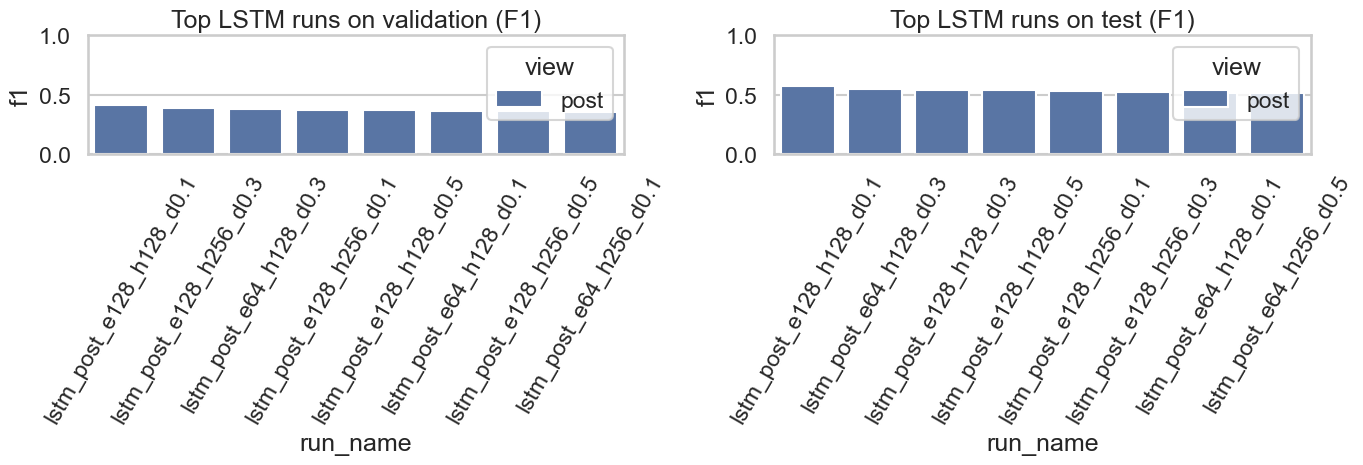

Saved: c:\Users\223114186\Desktop\System_Call_Based_Intrusion_Detection\syscall-anomaly-detection\reports\figures\lstm_ablation_f1_top8.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_val = ablation_df[ablation_df['split'] == 'val'].sort_values('f1', ascending=False).head(8)
sns.barplot(data=plot_val, x='run_name', y='f1', hue='view', ax=axes[0])
axes[0].set_title('Top LSTM runs on validation (F1)')
axes[0].tick_params(axis='x', rotation=60)
axes[0].set_ylim(0, 1)

plot_test = ablation_df[ablation_df['split'] == 'test'].sort_values('f1', ascending=False).head(8)
sns.barplot(data=plot_test, x='run_name', y='f1', hue='view', ax=axes[1])
axes[1].set_title('Top LSTM runs on test (F1)')
axes[1].tick_params(axis='x', rotation=60)
axes[1].set_ylim(0, 1)

fig.tight_layout()
lstm_fig_path = fig_dir / 'lstm_ablation_f1_top8.png'
fig.savefig(lstm_fig_path, dpi=150)
plt.show()
plt.close(fig)

print('Saved:', lstm_fig_path)

## Scientific Position After Sequential Training

Temporal modelling yields targeted gains in decision balance, particularly in false-alarm control at the chosen operating point. However, the strongest frequency-based baselines remain highly competitive on global ranking criteria.

The evidence therefore supports a nuanced conclusion: sequence order contributes useful but not dominant signal in ADFA-LD under the current feature granularity. The remaining gap is likely linked to representational limits shared by both model families rather than to optimisation alone.